# Mirror-CFE fuer MNIST 7 vs. 9 — Paper-Code (`mirror_cfe.py`)

Dieses Notebook uebernimmt die beiden Routinen aus dem Paper-Code **1:1** und haengt sie an das
7-vs-9-Setup (torchvision-`resnet18` + `MirrorDecoder`).

Anders als `mirrorcfe-mnist.ipynb` (eigene Variante: L-BFGS auf **Softmax-Wahrscheinlichkeiten**,
20 Iterationen) wird hier die exakte Paper-Route benutzt:

* **`batch_mirror_points`** — geometrische Spiegelung auf der *ganzen* Feature-Map, Skalierung mit
  \(\lVert W\rVert^2\) (Projektion auf die Hyperebene + Spiegelung).
* **`get_mirror_points`** — L-BFGS auf **rohen Logits**, Ziel = **vertauschte Logits**
  (`swapped_logits`), Verlust \(\lVert y-\text{swapped}\rVert^2\), **10 Iterationen**, `lr=0.1`.

Klassenkonvention: **7 → 0, 9 → 1**. Feature-Map `layer4` = `(B, 512, 4, 4)`. Laeuft lokal ueber
die Projekt-`.venv` (Apple MPS).

## Imports und Geraet

In [1]:
import os
import ssl
import numpy as np
from pathlib import Path

try:
    import certifi
    ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())
except ImportError:
    ssl._create_default_https_context = ssl._create_unverified_context

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
from torch.utils.data import DataLoader, Subset
from torchvision import transforms, datasets
from torchvision.models import resnet18
import matplotlib.pyplot as plt

torch.manual_seed(2024)
np.random.seed(2024)
DEVICE = torch.device('cuda' if torch.cuda.is_available()
                      else 'mps' if torch.backends.mps.is_available() else 'cpu')
print('Geraet:', DEVICE)

Geraet: mps


## Pfade und Konstanten

In [2]:
PROJ = Path.cwd()
while PROJ.name and not (PROJ / 'mnist_7v9_resnet18.pth').exists() and PROJ != PROJ.parent:
    PROJ = PROJ.parent
DATA_DIR    = PROJ / 'data'
PTH_PATH    = PROJ / 'mnist_7v9_resnet18.pth'
DECODER_PTH = PROJ / 'Counterfactuals' / 'Mirror' / 'mirror_decoder_mnist.pth'
OUT_DIR     = PROJ / 'Counterfactuals' / 'Mirror'

IMG_SIZE    = 28
BATCH_SIZE  = 16
MEAN, STD   = 0.1307, 0.3081
DIGITS      = (7, 9)
CLASS_NAMES = {0: '7', 1: '9'}      # 7 -> 0, 9 -> 1

print('Modell  vorhanden:', PTH_PATH.exists())
print('Decoder vorhanden:', DECODER_PTH.exists())

Modell  vorhanden: True
Decoder vorhanden: True


## Daten (MNIST-Test, nur 7/9)

In [3]:
eval_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((MEAN,), (STD,)),
])

def mnist_subset(train):
    ds = datasets.MNIST(root=str(DATA_DIR), train=train, download=True, transform=eval_transforms)
    idx = torch.where((ds.targets == DIGITS[0]) | (ds.targets == DIGITS[1]))[0]
    ds.targets = (ds.targets == DIGITS[1]).long()
    return ds, idx.tolist()

base_ds, test_indices = mnist_subset(train=False)
test_dataset = Subset(base_ds, test_indices)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
print('Test-Set:', len(test_dataset))

Test-Set: 2037


## Klassifikator (torchvision-`resnet18`, 28×28-Stamm)

Stamm fuer 28×28 angepasst: `conv1` = 3×3/Stride 1, `maxpool` = Identity, `fc` = Linear(512, 2).

In [4]:
def build_model():
    m = resnet18(weights=None)
    m.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)
    m.maxpool = nn.Identity()
    m.fc = nn.Linear(512, 2)
    return m

model = build_model().to(DEVICE)
model.load_state_dict(torch.load(PTH_PATH, map_location=DEVICE))
model.eval()
for p in model.parameters():
    p.requires_grad = False
print('Modell geladen')

def extract_feature_maps(model, images):
    """layer4-Feature-Map. Rueckgabe: (B, 512, 4, 4)."""
    feat = []
    hook = model.layer4.register_forward_hook(lambda m, i, o: feat.append(o))
    with torch.no_grad():
        _ = model(images)
    hook.remove()
    return feat[0]

Modell geladen


## Paper-Code (`mirror_cfe.py`) — 1:1 uebernommen

Die folgenden zwei Funktionen sind **wortgleich** aus dem Paper-Code uebernommen (nur das Wiring
darum herum ist angepasst):

* `get_mirror_points` — L-BFGS auf rohen Logits, Ziel = vertauschte Logits, 10 Iterationen.
* `batch_mirror_points` — geometrische Spiegelung auf der Feature-Map, Skalierung mit \(\lVert W\rVert^2\).

In [5]:
def get_mirror_points(classifier, mirror_point_fv, pred_source_logits, source_labels, cfe_labels):
    swapped_logits = pred_source_logits.clone().detach()
    tmp = swapped_logits[torch.arange(cfe_labels.shape[0]), cfe_labels]
    swapped_logits[torch.arange(cfe_labels.shape[0]), cfe_labels] = swapped_logits[torch.arange(cfe_labels.shape[0]), source_labels]
    swapped_logits[torch.arange(cfe_labels.shape[0]), source_labels] = tmp

    swapped_logits = Variable(swapped_logits, requires_grad=True)
    z = Variable(mirror_point_fv, requires_grad=True)
    optimizer = torch.optim.LBFGS([z], lr=0.1)

    # Loss function
    def loss_function():
        classifier.eval()
        y = classifier.fc(torch.flatten(F.adaptive_avg_pool2d(z, (1, 1)), 1))
        loss = torch.norm(y - swapped_logits) ** 2  # Squared L2 norm between y and q
        return loss

    num_iterations = 10
    for i in range(num_iterations):
        # Closure for LBFGS
        def closure():
            optimizer.zero_grad()
            loss = loss_function()
            loss.backward()
            return loss

        optimizer.step(closure)

    return z


def batch_mirror_points(x0_batch, W_batch, b_batch):
    batch_size, feature_dim, h, w = x0_batch.shape
    x0_batch = x0_batch.view(batch_size, feature_dim, -1)
    W_batch = W_batch.view(batch_size, feature_dim, 1)     # (batch_size, 512, 1)
    b_batch = b_batch.view(batch_size, 1, 1)               # Broadcast across spatial dim if needed

    dot_product = torch.bmm(W_batch.transpose(1, 2), x0_batch).squeeze(1)          # (batch_size, HW)
    norm_W_squared = torch.sum(W_batch * W_batch, dim=1, keepdim=True)             # (batch_size, 1, 1)
    projection = x0_batch - (dot_product.unsqueeze(1) + b_batch) / norm_W_squared * W_batch
    # Calculate the mirrored points
    mirrored_points = 2 * projection - x0_batch
    return mirrored_points.view(batch_size, feature_dim, h, w), projection.view(batch_size, feature_dim, h, w)

## Mirror-CFE-Pipeline (Wiring an das Paper)

Die Pro-Sample-Hyperebene ist die Differenz der beiden `fc`-Zeilen (Quelle → Ziel):
\(W_m = W_{\text{tgt}}-W_{\text{src}}\), \(b_m = b_{\text{tgt}}-b_{\text{src}}\). Fuer 7↔9 ist
das Ziel immer die jeweils andere Klasse. Dann: erst `batch_mirror_points` (geometrische Spiegelung),
danach `get_mirror_points` (L-BFGS-Logit-Angleich).

In [6]:
def get_boundary_params(model):
    W = model.fc.weight.data     # (2, 512)
    b = model.fc.bias.data       # (2,)
    return W, b

def compute_mirror_cfe_paper(model, images, device):
    """Paper-Pipeline: geometrische Spiegelung + L-BFGS-Logit-Angleich."""
    model.eval()
    images = images.to(device)
    W, b = get_boundary_params(model)

    with torch.no_grad():
        source_image_logits = model(images)                 # (B, 2)
        source_labels = source_image_logits.argmax(dim=1)   # Quellklasse
        cfe_labels = 1 - source_labels                      # Zielklasse (7<->9)

    recon_source_lvs = extract_feature_maps(model, images)  # (B, 512, 4, 4)

    # Pro-Sample-Hyperebene = Differenz der beiden fc-Zeilen (Quelle -> Ziel).
    Wm = (W[cfe_labels] - W[source_labels]).to(device)      # (B, 512)
    bm = (b[cfe_labels] - b[source_labels]).to(device)      # (B,)

    # 1) Geometrische Spiegelung auf der ganzen Feature-Map.
    mirror_point_fv, _ = batch_mirror_points(
        recon_source_lvs.clone().detach(), Wm.detach(), bm.detach())

    # 2) L-BFGS-Verfeinerung auf rohen Logits.
    mirror_point_fv = get_mirror_points(
        model, mirror_point_fv, source_image_logits, source_labels, cfe_labels)

    return mirror_point_fv, cfe_labels, source_labels, source_image_logits

def predict_from_features(model, feature_maps):
    """P(Klasse 1 = '9')."""
    with torch.no_grad():
        pooled = F.adaptive_avg_pool2d(feature_maps, (1, 1))
        flat   = torch.flatten(pooled, 1)
        probs  = torch.softmax(model.fc(flat), dim=1)[:, 1]
    return probs

print('Mirror-CFE (Paper) definiert')

Mirror-CFE (Paper) definiert


## Mirror-Decoder (SSC = SPE + CSP)

Identisch zum Trainings-/Eval-Notebook: skip-connection-basierter `MirrorDecoder`, MPS-sicherer
Adaptive-Pool.

In [7]:
def _safe_adaptive_pool(x, size):
    if x.device.type == 'mps':
        return F.adaptive_avg_pool2d(x.cpu(), size).to(x.device)
    return F.adaptive_avg_pool2d(x, size)

class SPEBlock(nn.Module):
    def __init__(self, Ci, Hi, flk_ch=512, bottleneck_ch=128, flk_hw=4):
        super().__init__()
        self.Hi = Hi; self.flk_hw = flk_hw
        self.bottleneck = nn.Sequential(
            nn.Conv2d(Ci, bottleneck_ch, 1, bias=False),
            nn.BatchNorm2d(bottleneck_ch), nn.ReLU(inplace=True))
        self.decoder = nn.Sequential(
            nn.Conv2d(bottleneck_ch + flk_ch, Ci, 3, padding=1),
            nn.BatchNorm2d(Ci), nn.ReLU(inplace=True),
            nn.Upsample(size=(Hi, Hi), mode='bilinear', align_corners=False),
            nn.Conv2d(Ci, Ci, 3, padding=1),
            nn.BatchNorm2d(Ci), nn.ReLU(inplace=True))
    def forward(self, fi_s, flk):
        bi = _safe_adaptive_pool(self.bottleneck(fi_s), (self.flk_hw, self.flk_hw))
        return self.decoder(torch.cat([bi, flk], dim=1))

class SSC(nn.Module):
    def __init__(self, rho_l=0.1, rho_u=0.5):
        super().__init__()
        self.rho_l, self.rho_u = rho_l, rho_u
        self.spe1 = SPEBlock(64, 28); self.spe2 = SPEBlock(128, 14); self.spe3 = SPEBlock(256, 7)
    def csp_mask(self, flk, W, k, thw, src, tgt):
        B, C, H, Wd = flk.shape
        Uk = F.relu(torch.einsum('oc,bchw->bohw', W, flk))
        Nk = Uk / (Uk.amax(dim=(2, 3), keepdim=True) + 1e-8)
        rho = min(max(1.0 - k, self.rho_l), self.rho_u)
        idx = torch.arange(B, device=flk.device)
        Ns = (Nk[idx, src].unsqueeze(1) > rho).float()
        Nt = (Nk[idx, tgt].unsqueeze(1) > rho).float()
        M  = torch.clamp(Ns + Nt, 0, 1)
        return F.interpolate(M, size=thw, mode='nearest')
    def forward(self, f1, f2, f3, flk, W, k, src, tgt):
        u1, u2, u3 = self.spe1(f1, flk), self.spe2(f2, flk), self.spe3(f3, flk)
        m1 = self.csp_mask(flk, W, k, (28, 28), src, tgt)
        m2 = self.csp_mask(flk, W, k, (14, 14), src, tgt)
        m3 = self.csp_mask(flk, W, k, (7, 7), src, tgt)
        return (1-m1)*f1+m1*u1, (1-m2)*f2+m2*u2, (1-m3)*f3+m3*u3

class MirrorDecoder(nn.Module):
    def __init__(self, rho_l=0.1, rho_u=0.5):
        super().__init__()
        self.ssc = SSC(rho_l, rho_u)
        self.up1 = self._up(512, 256, 7)
        self.up2 = self._up(512, 128, 14)
        self.up3 = self._up(256, 64, 28)
        self.up4 = self._conv(128, 32)
        self.out_conv = nn.Sequential(nn.Conv2d(32, 1, 3, padding=1), nn.Tanh())
    def _up(self, ic, oc, size):
        return nn.Sequential(
            nn.Upsample(size=(size, size), mode='bilinear', align_corners=False),
            nn.Conv2d(ic, oc, 3, padding=1), nn.BatchNorm2d(oc), nn.ReLU(inplace=True),
            nn.Conv2d(oc, oc, 3, padding=1), nn.BatchNorm2d(oc), nn.ReLU(inplace=True))
    def _conv(self, ic, oc):
        return nn.Sequential(
            nn.Conv2d(ic, oc, 3, padding=1), nn.BatchNorm2d(oc), nn.ReLU(inplace=True),
            nn.Conv2d(oc, oc, 3, padding=1), nn.BatchNorm2d(oc), nn.ReLU(inplace=True))
    def _decode(self, flk, fp1, fp2, fp3):
        x = self.up1(flk); x = torch.cat([x, fp3], 1)
        x = self.up2(x);   x = torch.cat([x, fp2], 1)
        x = self.up3(x);   x = torch.cat([x, fp1], 1)
        x = self.up4(x)
        return self.out_conv(x)
    def forward(self, flk, f1, f2, f3, W, k, src, tgt):
        fp1, fp2, fp3 = self.ssc(f1, f2, f3, flk, W, k, src, tgt)
        return self._decode(flk, fp1, fp2, fp3)

def extract_all_features(model, images):
    feats = {}; hooks = []
    lm = {'f1': model.layer1, 'f2': model.layer2, 'f3': model.layer3, 'f4': model.layer4}
    for n, l in lm.items():
        hooks.append(l.register_forward_hook(lambda m, i, o, n=n: feats.update({n: o})))
    with torch.no_grad(): _ = model(images)
    for h in hooks: h.remove()
    return feats['f1'], feats['f2'], feats['f3'], feats['f4']

def denormalise(tensor):
    return (tensor * STD + MEAN).clamp(0, 1)

def tanh_to_img(t):
    return (t + 1.0) / 2.0

dec_ckpt = torch.load(DECODER_PTH, map_location=DEVICE, weights_only=False)
decoder  = MirrorDecoder(rho_l=0.1, rho_u=0.5).to(DEVICE)
decoder.load_state_dict(dec_ckpt['model_state_dict'])
decoder.eval()
Wmat = model.fc.weight.data.clone().to(DEVICE)
print('Mirror-Decoder geladen')

Mirror-Decoder geladen


## Latent-Flip-Rate (Paper-Code)

In [8]:
n_batches = 10
total_flip = total_images = 0
for batch_imgs, batch_lbls in list(test_loader)[:n_batches]:
    m_fv, c_lbls, s_lbls, s_logits = compute_mirror_cfe_paper(model, batch_imgs, DEVICE)
    cfe_p = predict_from_features(model, m_fv).cpu()
    preds = (cfe_p >= 0.5).long()
    total_flip   += (preds == c_lbls.cpu()).sum().item()
    total_images += len(batch_lbls)
print(f'Latent-Flip-Rate (Paper-Code): {total_flip}/{total_images} = {total_flip/total_images:.2%}')

Latent-Flip-Rate (Paper-Code): 160/160 = 100.00%


## Decodieren und visualisieren: Original | CFE | Differenz

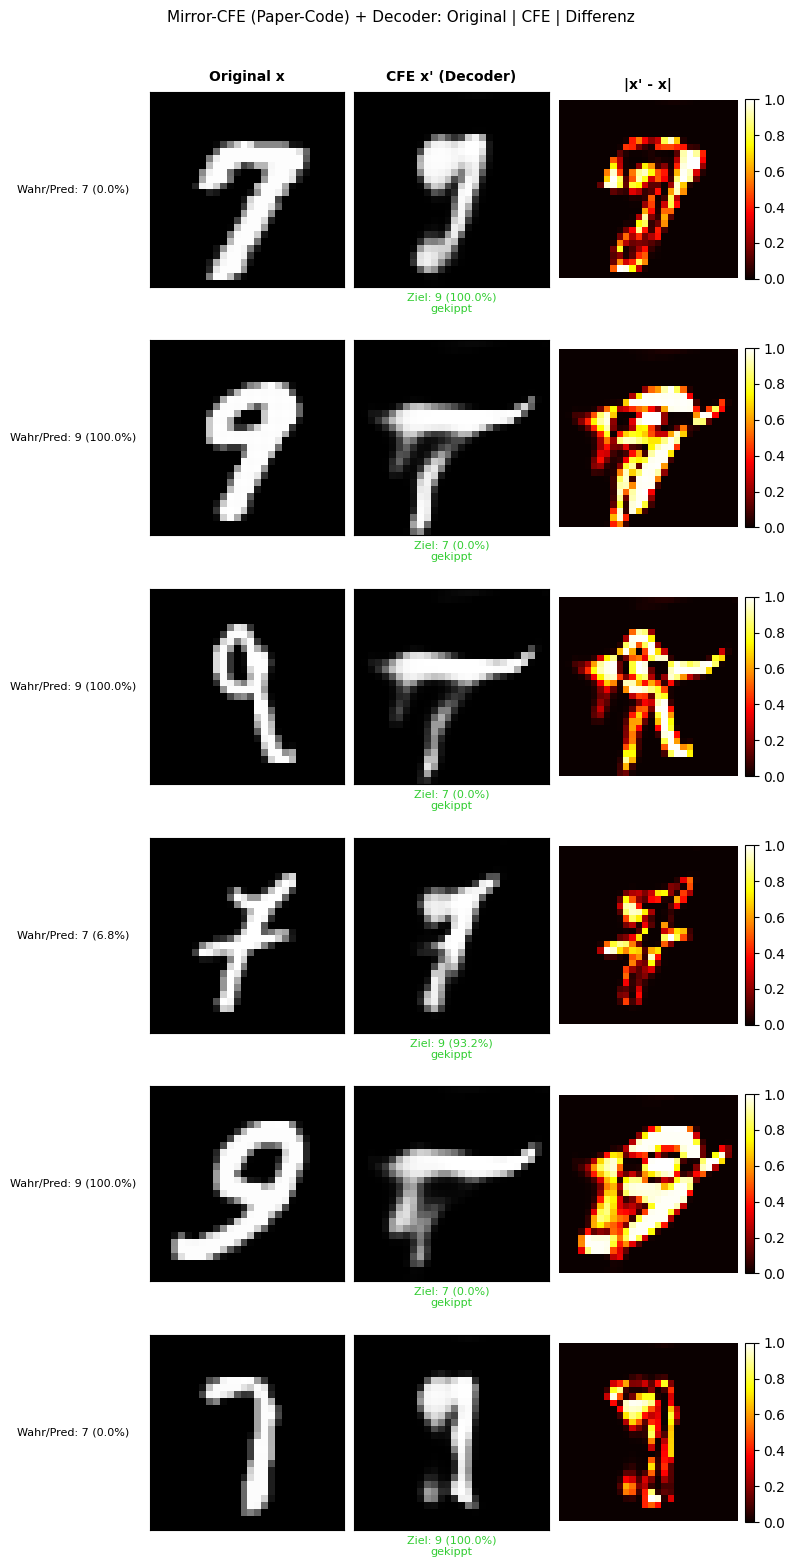

Gespeichert -> /Users/sophiapaoli/Nextcloud/Documents/Master/Semester_2/Praxisseminar/Explaining_Image_Classification/Counterfactuals/Mirror/mirror_cfe_decoded_mnist_paper.png


In [9]:
def visualise_decoder_cfe(model, decoder, Wmat, images, mirror_fv, cfe_labels, source_labels,
                          orig_probs, class_names, n_samples=6, save_path='mirror_cfe_decoded.png'):
    model.eval(); decoder.eval()
    images = images.to(DEVICE); n = min(n_samples, images.size(0))
    f1, f2, f3, f4 = extract_all_features(model, images[:n])
    src_n = source_labels[:n].to(DEVICE); tgt_n = cfe_labels[:n].to(DEVICE)
    with torch.no_grad():
        cfe_imgs = decoder(mirror_fv[:n].detach(), f1, f2, f3, Wmat, 1.0, src_n, tgt_n)
    cfe_probs_val = predict_from_features(model, mirror_fv[:n]).cpu().numpy()
    orig_probs_np = orig_probs[:n].detach().cpu().numpy()

    fig, axes = plt.subplots(n, 3, figsize=(8, n * 2.6))
    if n == 1: axes = axes[np.newaxis, :]
    for col, t_ in enumerate(["Original x", "CFE x' (Decoder)", "|x' - x|"]):
        axes[0, col].set_title(t_, fontsize=10, fontweight='bold', pad=8)
    for i in range(n):
        orig_np = denormalise(images[i, 0].cpu()).numpy()
        cfe_np  = tanh_to_img(cfe_imgs[i, 0].detach().cpu()).numpy().clip(0, 1)
        diff_np = np.abs(cfe_np - orig_np)
        diff_np = (diff_np - diff_np.min()) / (diff_np.max() + 1e-8)
        src_lbl = source_labels[i].item(); cfe_lbl = cfe_labels[i].item()
        flipped = int(cfe_probs_val[i] >= 0.5) == cfe_lbl
        axes[i, 0].imshow(orig_np, cmap='gray')
        axes[i, 0].set_ylabel(f'Wahr/Pred: {class_names[src_lbl]} ({orig_probs_np[i]:.1%})',
                              fontsize=8, rotation=0, labelpad=55, va='center')
        axes[i, 0].set_xticks([]); axes[i, 0].set_yticks([])
        axes[i, 1].imshow(cfe_np, cmap='gray')
        fc = 'limegreen' if flipped else 'tomato'
        axes[i, 1].set_xlabel(f'Ziel: {class_names[cfe_lbl]} ({cfe_probs_val[i]:.1%})\n'
                              f'{"gekippt" if flipped else "nicht gekippt"}', fontsize=8, color=fc)
        axes[i, 1].set_xticks([]); axes[i, 1].set_yticks([])
        im = axes[i, 2].imshow(diff_np, cmap='hot', vmin=0, vmax=1)
        plt.colorbar(im, ax=axes[i, 2], fraction=0.046, pad=0.04); axes[i, 2].axis('off')
    plt.suptitle("Mirror-CFE (Paper-Code) + Decoder: Original | CFE | Differenz",
                 fontsize=11, y=1.005)
    plt.tight_layout()
    plt.savefig(save_path, dpi=120, bbox_inches='tight'); plt.show()
    print(f'Gespeichert -> {save_path}')

sample_images, sample_labels = next(iter(test_loader))
m_fv, c_lbls, s_lbls, s_logits = compute_mirror_cfe_paper(model, sample_images, DEVICE)
orig_probs = torch.softmax(s_logits, dim=1)[:, 1]
visualise_decoder_cfe(
    model, decoder, Wmat, sample_images, m_fv, c_lbls, s_lbls, orig_probs, CLASS_NAMES,
    n_samples=6, save_path=str(OUT_DIR / 'mirror_cfe_decoded_mnist_paper.png'))